In [1]:
# Install YOLOv8
!pip install ultralytics -q

import os
import glob
import shutil
import random
import xml.etree.ElementTree as ET
from tqdm.notebook import tqdm
from ultralytics import YOLO
import yaml
import matplotlib.pyplot as plt
import cv2

print("Package dependencies resolved")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.9 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Package dependencies resolved


In [2]:
# Create new YOLO yaml dataset configuration file
!rm -f /kaggle/working/data.yaml
data = {
    "path": "/kaggle/input/datasets/christal87/synthetic-plates-192x64/dataset",
    "train": "images/train",
    "val": "images/val",
    "nc": 37,
    "names": [
        "0","1","2","3","4","5","6","7","8","9",
        "A","B","C","D","E","F","G","H","I","J",
        "K","L","M","N","O","P","Q","R","S","T",
        "U","V","W","X","Y","Z","-"
    ]
}

with open("data.yaml", "w") as f:
    yaml.dump(data, f)

print("data.yaml created!")

data.yaml created!


In [3]:
#Remove pre-existing data
!rm -rf /kaggle/working/runs

# Load XL model
#model = YOLO('yolo26x.pt')
# Load L model
#model = YOLO('yolo26l.pt')
# Load M model
#model = YOLO('yolo26m.pt')
# Load S model
#model = YOLO('yolo26s.pt')
# Load smallest (nano) model
model = YOLO('yolo26n.pt')
"""
# Train only for 50 epochs
results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=50,
    imgsz=192,
    batch=128,
    name='plate_txt_detection_model',
    project='/kaggle/working/runs',
    plots=True,
    rect=True,
    degrees=0,
    shear=0,
    perspective=0,
    flipud=0,
)
"""

"""
# Train w/ automatic augmentation, 800epochs that stop after no increase for 150 using patience
# Trained for 0.843 h, 0.897 mAP50, increased detections for a small 433 image dataset vs fewer epochs
results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=800,
    patience=150,
    imgsz=192,
    batch=128,
    name='plate_txt_detection_model',
    project='/kaggle/working/runs',
    augment = False,
    rect=True,
    plots=True,
    degrees=0,
    shear=0,
    perspective=0,
    flipud=0,
)
"""

"""
# Train w/ augmix augmentation
results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=50,
    imgsz=192,
    batch=128,
    name='plate_txt_detection_model',
    project='/kaggle/working/runs',
    augment = False,
    auto_augment= 'augmix',
    rect=True,
    plots=True,
    degrees=0,
    shear=0,
    perspective=0,
    flipud=0,
)
"""

# Train w/ plot and automatic augmentation, large dataset, 35epochs that stop after no increase for 7 using patience on 25,500 train and 1000 val images
# Trained for ~1h, less detections, less mAP50 than with small dataset + way more epochs, increase epochs?
results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=35,
    patience=7,
    imgsz=192,
    batch=128,
    name='plate_txt_detection_model',
    project='/kaggle/working/runs',
    augment = False,
    rect=True,
    plots=True,
    degrees=0,
    shear=0,
    perspective=0,
    flipud=0,
)
# Train w/ plot and automatic augmentation, large dataset, 70epochs that stop after no increase for 14 using patience on 25,500 train and 1000 val images
# Trained for ~1h, less detections, less mAP50 than with small dataset + way more epochs, increase epochs?
"""
results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=70,
    patience=14,
    imgsz=192,
    batch=128,
    name='plate_txt_detection_model',
    project='/kaggle/working/runs',
    augment = False,
    rect=True,
    plots=True,
    degrees=0,
    shear=0,
    perspective=0,
    flipud=0,
)
"""

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=192, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_txt_detection_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

"\nresults = model.train(\n    data='/kaggle/working/data.yaml',\n    epochs=70,\n    patience=14,\n    imgsz=192,\n    batch=128,\n    name='plate_txt_detection_model',\n    project='/kaggle/working/runs',\n    augment = False,\n    rect=True,\n    plots=True,\n    degrees=0,\n    shear=0,\n    perspective=0,\n    flipud=0,\n)\n"

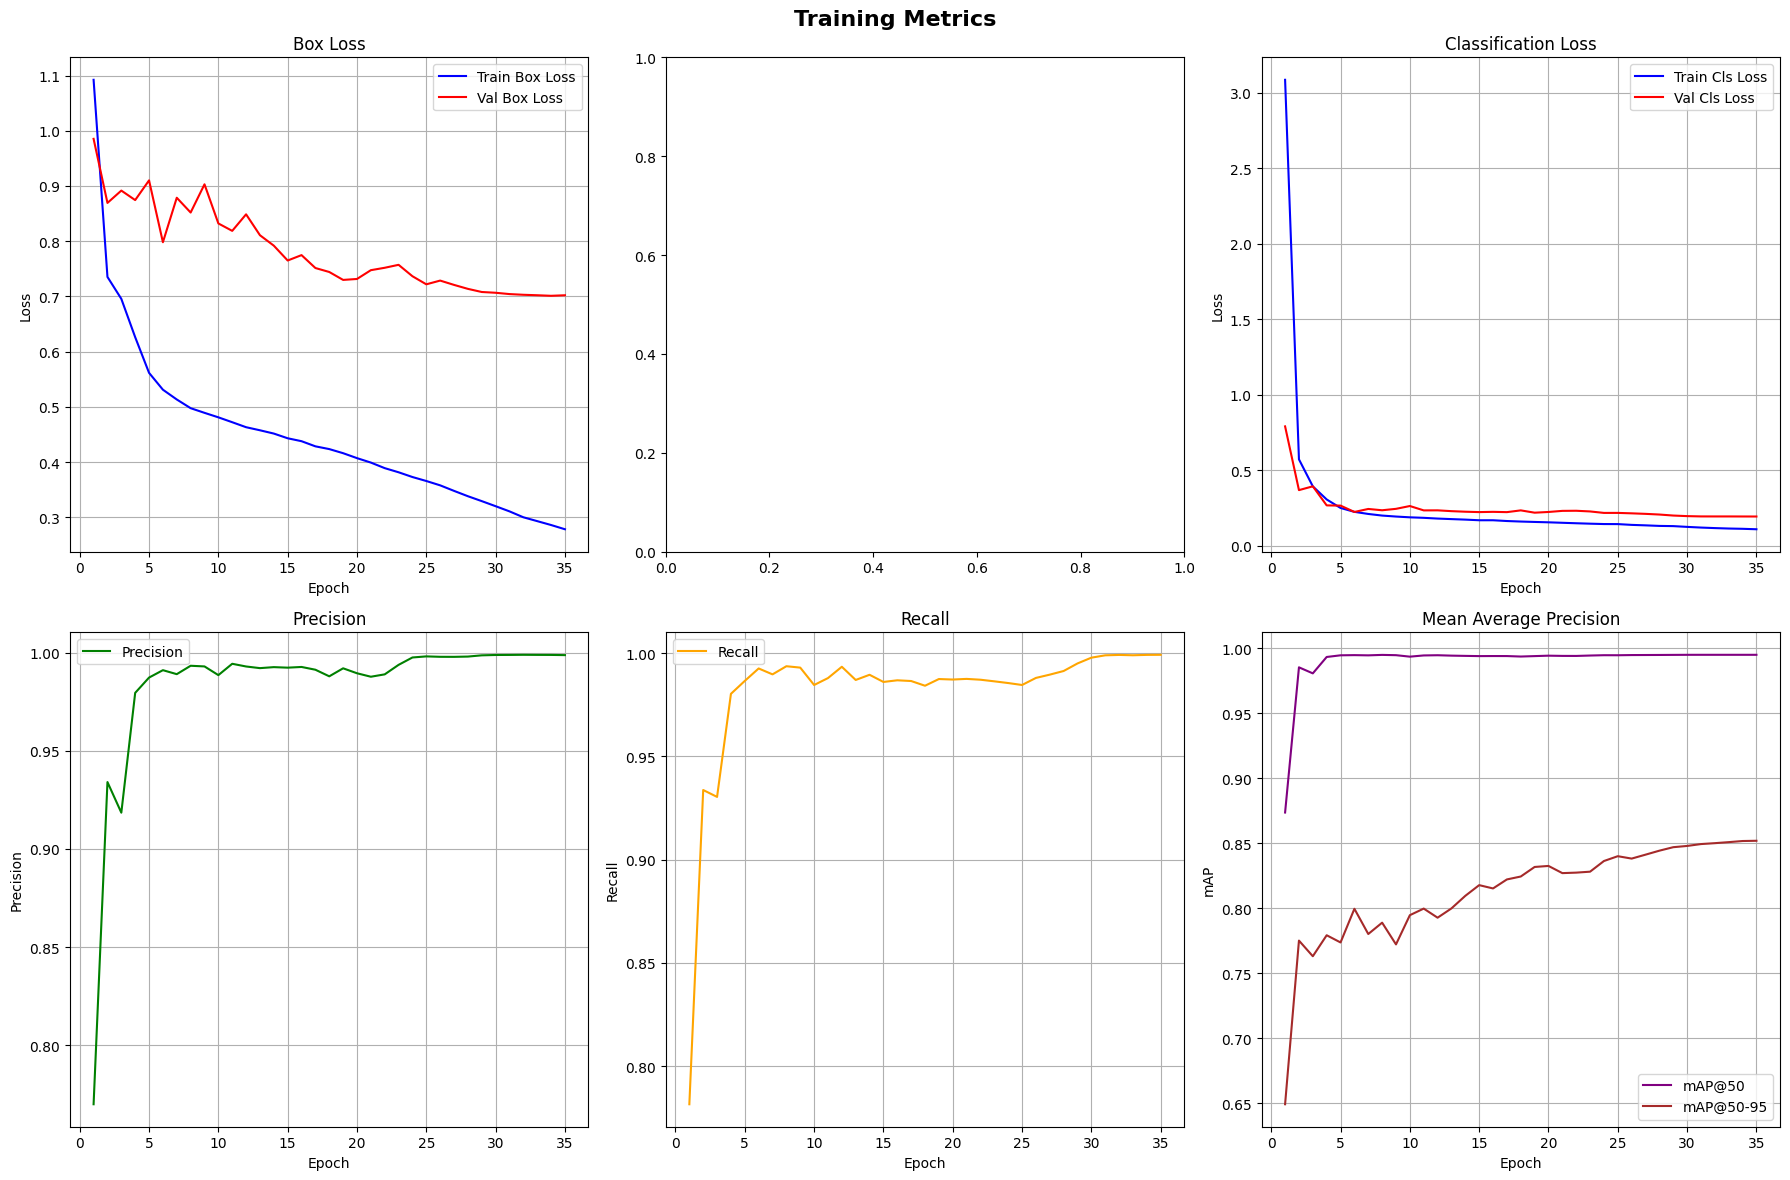


=== Final Training Metrics ===
Final Precision: 0.9987
Final Recall: 0.9991
Final mAP@50: 0.9950
Final mAP@50-95: 0.8519


In [4]:

# Import additional libraries for visualization
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import glob
from pathlib import Path

# Function to plot training metrics
def plot_training_metrics(results_path='runs/plate_txt_detection_model'):
    """
    Plot training metrics from YOLO training results
    """
    # Read results.csv if it exists
    csv_path = f'{results_path}/results.csv'
    
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()  # Remove any whitespace
        
        # Create subplots
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Training Metrics', fontsize=16, fontweight='bold')
        
        # Plot training and validation loss
        if 'train/box_loss' in df.columns and 'val/box_loss' in df.columns:
            axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue')
            axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='red')
            axes[0, 0].set_title('Box Loss')
            axes[0, 0].set_xlabel('Epoch')
            axes[0, 0].set_ylabel('Loss')
            axes[0, 0].legend()
            axes[0, 0].grid(True)
        
        # Plot objectness loss
        if 'train/obj_loss' in df.columns and 'val/obj_loss' in df.columns:
            axes[0, 1].plot(df['epoch'], df['train/obj_loss'], label='Train Obj Loss', color='blue')
            axes[0, 1].plot(df['epoch'], df['val/obj_loss'], label='Val Obj Loss', color='red')
            axes[0, 1].set_title('Objectness Loss')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('Loss')
            axes[0, 1].legend()
            axes[0, 1].grid(True)
        
        # Plot class loss
        if 'train/cls_loss' in df.columns and 'val/cls_loss' in df.columns:
            axes[0, 2].plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss', color='blue')
            axes[0, 2].plot(df['epoch'], df['val/cls_loss'], label='Val Cls Loss', color='red')
            axes[0, 2].set_title('Classification Loss')
            axes[0, 2].set_xlabel('Epoch')
            axes[0, 2].set_ylabel('Loss')
            axes[0, 2].legend()
            axes[0, 2].grid(True)
        
        # Plot Precision
        if 'metrics/precision(B)' in df.columns:
            axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='green')
            axes[1, 0].set_title('Precision')
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].set_ylabel('Precision')
            axes[1, 0].legend()
            axes[1, 0].grid(True)
        
        # Plot Recall
        if 'metrics/recall(B)' in df.columns:
            axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='orange')
            axes[1, 1].set_title('Recall')
            axes[1, 1].set_xlabel('Epoch')
            axes[1, 1].set_ylabel('Recall')
            axes[1, 1].legend()
            axes[1, 1].grid(True)
        
        # Plot mAP@50 and mAP@50-95
        if 'metrics/mAP50(B)' in df.columns:
            axes[1, 2].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='purple')
            if 'metrics/mAP50-95(B)' in df.columns:
                axes[1, 2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='brown')
            axes[1, 2].set_title('Mean Average Precision')
            axes[1, 2].set_xlabel('Epoch')
            axes[1, 2].set_ylabel('mAP')
            axes[1, 2].legend()
            axes[1, 2].grid(True)
        
        plt.tight_layout()
        plt.show()
        
        # Print final metrics
        print("\n=== Final Training Metrics ===")
        final_epoch = df.iloc[-1]
        if 'metrics/precision(B)' in df.columns:
            print(f"Final Precision: {final_epoch['metrics/precision(B)']:.4f}")
        if 'metrics/recall(B)' in df.columns:
            print(f"Final Recall: {final_epoch['metrics/recall(B)']:.4f}")
        if 'metrics/mAP50(B)' in df.columns:
            print(f"Final mAP@50: {final_epoch['metrics/mAP50(B)']:.4f}")
        if 'metrics/mAP50-95(B)' in df.columns:
            print(f"Final mAP@50-95: {final_epoch['metrics/mAP50-95(B)']:.4f}")
    else:
        print(f"Results file not found at {csv_path}")

# Call the function to plot metrics
plot_training_metrics()


image 1/1 /kaggle/input/datasets/christal87/synthetic-plates-192x64/dataset/images/val/plate_20300.png: 64x192 1 2, 1 4, 1 8, 1 B, 1 E, 1 H, 1 U, 1 -, 52.1ms
Speed: 0.5ms preprocess, 52.1ms inference, 0.5ms postprocess per image at shape (1, 3, 64, 192)

image 1/1 /kaggle/input/datasets/christal87/synthetic-plates-192x64/dataset/images/val/plate_47974.png: 64x192 1 7, 2 8s, 1 D, 1 F, 1 T, 1 U, 1 -, 9.9ms
Speed: 0.4ms preprocess, 9.9ms inference, 0.4ms postprocess per image at shape (1, 3, 64, 192)

image 1/1 /kaggle/input/datasets/christal87/synthetic-plates-192x64/dataset/images/val/plate_34464.png: 64x192 1 1, 1 2, 1 9, 1 A, 1 L, 1 O, 1 Y, 1 -, 9.7ms
Speed: 0.4ms preprocess, 9.7ms inference, 0.4ms postprocess per image at shape (1, 3, 64, 192)

image 1/1 /kaggle/input/datasets/christal87/synthetic-plates-192x64/dataset/images/val/plate_19327.png: 64x192 1 0, 1 1, 1 4, 1 J, 1 T, 1 X, 1 -, 9.8ms
Speed: 0.4ms preprocess, 9.8ms inference, 0.4ms postprocess per image at shape (1, 3, 64, 

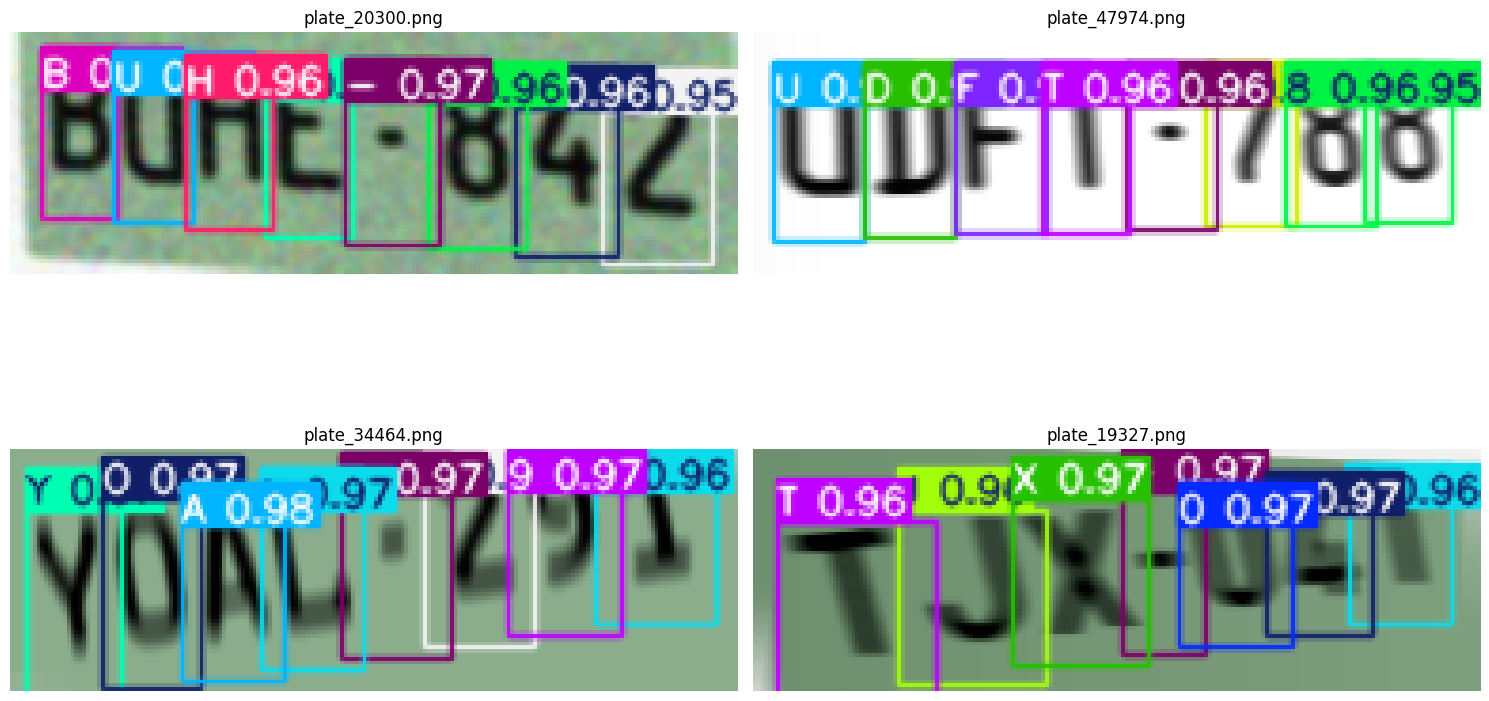

In [5]:
# Load currently trained model after done
base_dir = '/kaggle/input/datasets/christal87/synthetic-plates-192x64/dataset/images'
best_model_path = '/kaggle/working/runs/plate_txt_detection_model/weights/best.pt'
model_trained = YOLO(best_model_path)

# Take four pictures from the validation folder
val_images_path = f'{base_dir}/val'
test_images = glob.glob(f'{val_images_path}/*.png')[:4]
plt.figure(figsize=(15, 10))

for i, img_path in enumerate(test_images):
    # Prediction result
    results = model_trained(img_path, conf=0.25)
    
    # Plot prediction results using opencv
    #res_plotted = results[0].plot()
    res_plotted = results[0].plot(font_size=8, line_width=1)
    plt.subplot(2, 2, i+1)
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.title(os.path.basename(img_path))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Copy best.pt to the root working directory for easy downloading
!rm -f /kaggle/working/plate_txt_detector_26n_synth_dataset_35it.pt
shutil.copy(best_model_path, '/kaggle/working/plate_txt_detector_26n_synth_dataset_35it_80kimg.pt')

print("Model saved as 'plate_txt_detector.pt'")

Model saved as 'plate_txt_detector.pt'


30

image 1/1 /kaggle/input/datasets/christal87/hu-plate-testimg/bow_hrk101.jpg: 128x192 2 1s, 1 H, 1 K, 1 O, 1 R, 1 -, 56.7ms
Speed: 0.8ms preprocess, 56.7ms inference, 0.5ms postprocess per image at shape (1, 3, 128, 192)

image 1/1 /kaggle/input/datasets/christal87/hu-plate-testimg/bow_kot311_realistic2.jpg: 64x192 1 1, 1 H, 1 K, 1 O, 11.2ms
Speed: 0.6ms preprocess, 11.2ms inference, 0.4ms postprocess per image at shape (1, 3, 64, 192)

image 1/1 /kaggle/input/datasets/christal87/hu-plate-testimg/bow_xxn632.jpg: 128x192 1 6, 1 C, 1 G, 1 L, 1 N, 2 Xs, 1 -, 10.7ms
Speed: 0.6ms preprocess, 10.7ms inference, 0.5ms postprocess per image at shape (1, 3, 128, 192)

image 1/1 /kaggle/input/datasets/christal87/hu-plate-testimg/bow_aaax926_realistic.jpg: 96x192 1 2, 1 A, 52.5ms
Speed: 0.6ms preprocess, 52.5ms inference, 0.4ms postprocess per image at shape (1, 3, 96, 192)

image 1/1 /kaggle/input/datasets/christal87/hu-plate-testimg/bow_lrs776.jpg: 64x192 1 6, 2 7s, 1 L, 1 R, 1 S, 1 -, 10.9ms

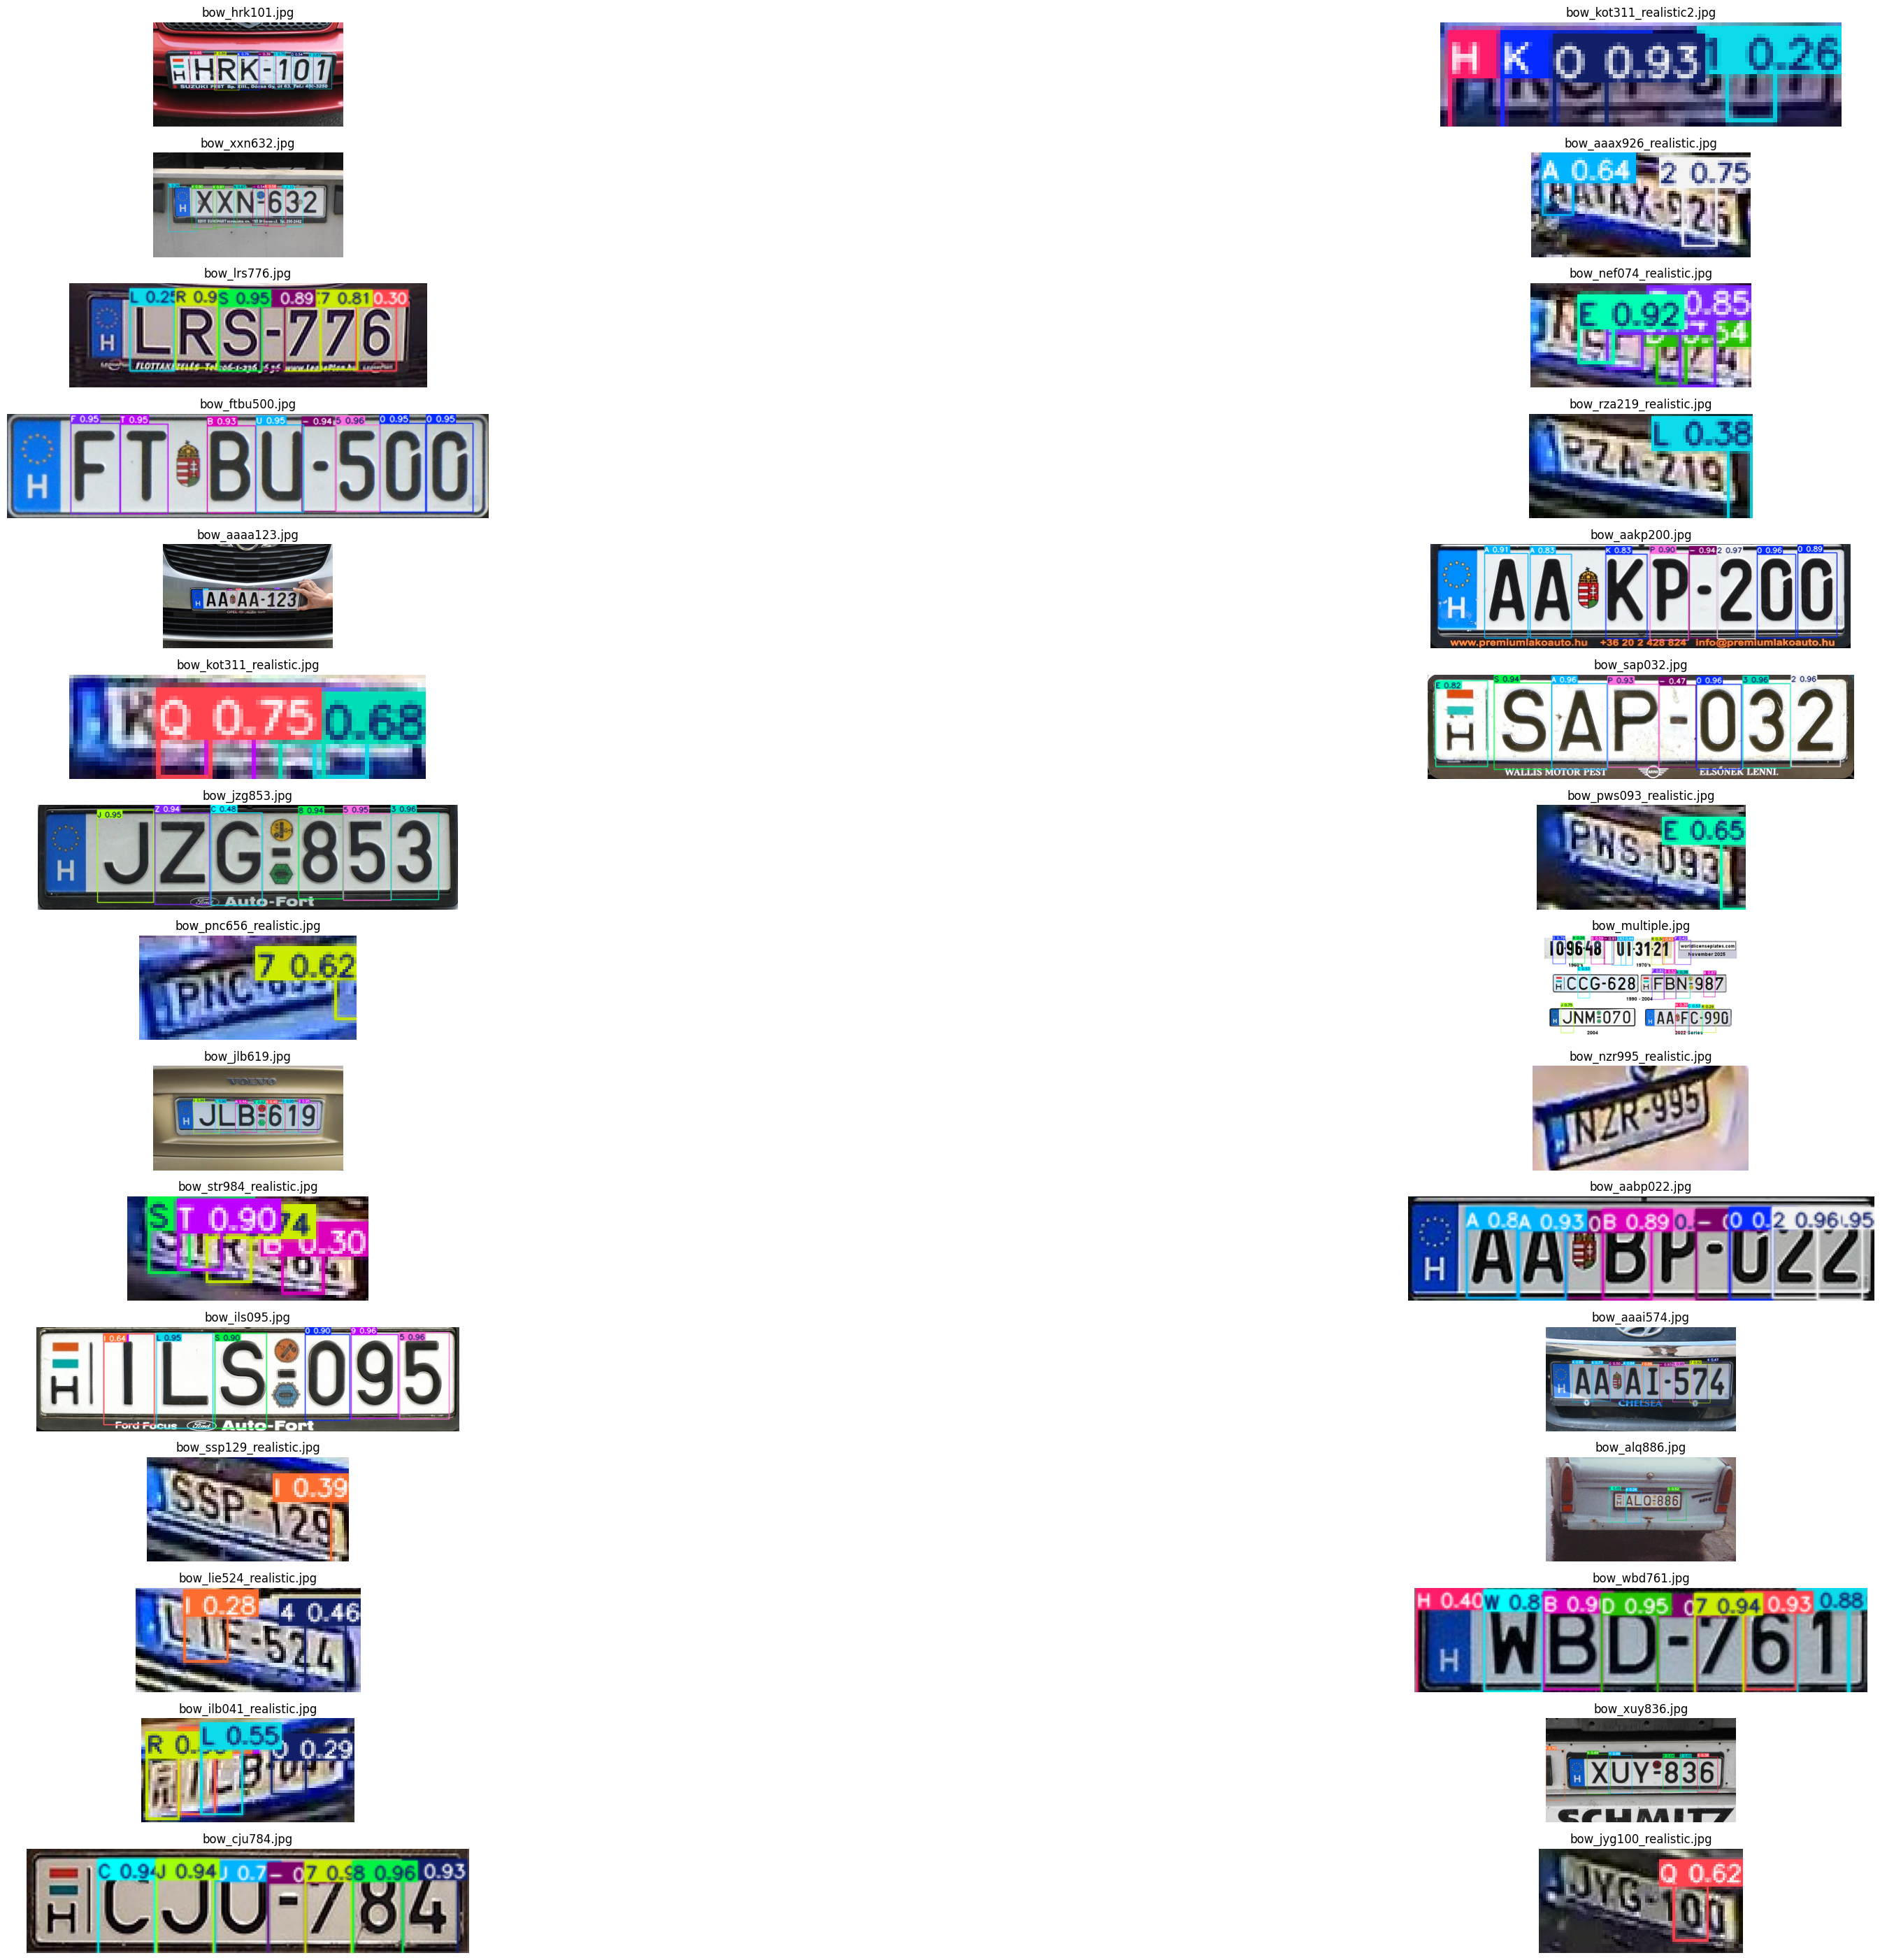

In [8]:
#Load arbitrary trained model after done and compare to fastanpr inference detections output dataset (yolov8n trt fp32 jetson orin nano)

saved_model_path = '/kaggle/working/plate_txt_detector_26n_synth_dataset_35it_80kimg.pt'
#saved_model_path = '/kaggle/working/glyph_detector_26s_synth_dataset.pt'
#saved_model_path = '/kaggle/working/glyph_detector_26m_synth_dataset.pt'
#saved_model_path = '/kaggle/working/glyph_detector_26l_synth_dataset.pt'
#saved_model_path = '/kaggle/working/glyph_detector_26x_synth_dataset.pt'
saved_model_trained = YOLO(saved_model_path)

# Take 32 pictures from validation folder
#saved_val_images_path = '/kaggle/input/datasets/christal87/hu-plate-glyphs-64px/fonts_dataset/images/val'
#saved_val_images_path = '/kaggle/input/datasets/christal87/hu-plate-testimg'
saved_val_images_path = '/kaggle/input/datasets/christal87/hu-plate-testimg'
#saved_test_images = glob.glob(f'{saved_val_images_path}/*.png')[:32]
#saved_test_images = glob.glob(f'{saved_val_images_path}/*.jpg')[:4]
saved_test_images = glob.glob(f'{saved_val_images_path}/bow_*.jpg')[:32]
print(len(saved_test_images))
#plt.figure(figsize=(20, 15))
plt.figure(figsize=(40, 30))

for i, img_path in enumerate(saved_test_images):
    # Prediction result
    results = saved_model_trained(img_path, conf=0.25)
    #results = saved_model_trained(img_path, conf=0.7)
    
    # Plot prediction results using opencv
    #res_plotted = results[0].plot()
    res_plotted = results[0].plot(font_size=8, line_width=1)
    #plt.subplot(16, 2, i+1)
    plt.subplot(16, 2, i+1)
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.title(os.path.basename(img_path))
    plt.axis('off')

plt.tight_layout()
plt.show()